## Câu 3.4.1 & 3.4.2 - Chuẩn hóa ma trận dữ liệu và xếp hạng theo trọng số mặc định

In [1]:
import pandas as pd
import numpy as np

# Đọc dữ liệu từ thư mục data nằm ngang hàng
df = pd.read_csv('../data/vietnam_sectors_2024.csv')

# Khai báo danh sách các cột chỉ số tác động tích cực và cột rủi ro
cols_good = ['growth_rate_2024_pct', 'gdp_share_2024_pct', 'spillover_coef_0_1', 
             'export_billion_USD', 'labor_million', 'ai_readiness_0_100']
col_bad = 'automation_risk_pct'

# Hàm chuẩn hóa Min-Max
def norm_good(x): return (x - x.min()) / (x.max() - x.min())
def norm_bad(x): return (x.max() - x) / (x.max() - x.min())

# Thực hiện chuẩn hóa
Xg = df[cols_good].apply(norm_good)
Xb = norm_bad(df[col_bad])

print("=== CÂU 3.4.1: MA TRẬN DỮ LIỆU ĐÃ CHUẨN HÓA MIN-MAX ===")
# Ghép các cột lại thành một ma trận hoàn chỉnh để in ra
df_norm = Xg.copy()
df_norm['automation_risk_pct_normalized'] = Xb
df_norm.insert(0, 'Sector', df['sector_name_vi'])
display(df_norm.round(3))

print("\n=== CÂU 3.4.2: XẾP HẠNG 10 NGÀNH THEO BỘ TRỌNG SỐ MẶC ĐỊNH ===")
# Bộ trọng số mặc định (Lưu ý: công thức trừ đi rủi ro, nhưng do hàm norm_bad đã đảo dấu 
# để biến rủi ro thấp thành điểm cao, nên chúng ta sẽ CỘNG phần điểm rủi ro đã đảo dấu này)
w_good = np.array([0.15, 0.15, 0.20, 0.15, 0.10, 0.20])
w_risk = 0.15

# Tính toán điểm chỉ số Priority
df['Priority'] = Xg.values @ w_good + w_risk * Xb.values
ranking_default = df[['sector_name_vi', 'Priority']].sort_values('Priority', ascending=False).reset_index(drop=True)
ranking_default.index += 1
display(ranking_default.round(4))

=== CÂU 3.4.1: MA TRẬN DỮ LIỆU ĐÃ CHUẨN HÓA MIN-MAX ===


,Sector,growth_rate_2024_pct,gdp_share_2024_pct,spillover_coef_0_1,export_billion_USD,labor_million,ai_readiness_0_100,automation_risk_pct_normalized
0,Nông-Lâm-Thủy sản,0.402,0.424,0.081,0.139,1.000,0.000,1.000
1,Công nghiệp chế biến chế tạo,0.974,1.000,0.774,1.000,0.868,0.548,0.351
2,Xây dựng,0.777,0.197,0.194,0.009,0.349,0.068,0.811
3,Khai khoáng,0.000,0.024,0.000,0.028,0.000,0.205,0.000
4,Bán buôn-bán lẻ,0.746,0.329,0.403,0.019,0.581,0.452,0.459
5,Tài chính-Ngân hàng-Bảo hiểm,0.769,0.107,0.887,0.004,0.019,0.781,0.081
6,Logistics-Vận tải-Kho bãi,1.000,0.122,0.677,0.011,0.128,0.370,0.541
7,Thông tin-Truyền thông-CNTT,0.813,0.047,1.000,0.612,0.025,1.000,0.730
8,Giáo dục-Đào tạo,0.685,0.047,0.565,0.000,0.143,0.315,0.892
9,Y tế-Chăm sóc sức khỏe,0.723,0.000,0.484,0.000,0.035,0.411,1.000



=== CÂU 3.4.2: XẾP HẠNG 10 NGÀNH THEO BỘ TRỌNG SỐ MẶC ĐỊNH ===


,sector_name_vi,Priority
1,Công nghiệp chế biến chế tạo,0.8500
2,Thông tin-Truyền thông-CNTT,0.7328
3,Tài chính-Ngân hàng-Bảo hiểm,0.4797
4,Logistics-Vận tải-Kho bãi,0.4733
5,Bán buôn-bán lẻ,0.4622
6,Y tế-Chăm sóc sức khỏe,0.4409
7,Giáo dục-Đào tạo,0.4338
8,Nông-Lâm-Thủy sản,0.4109
9,Xây dựng,0.3564
10,Khai khoáng,0.0489


## Câu 3.4.3 - Phân tích độ nhạy của trọng số AI Readiness ($a_6$) và vẽ Heatmap

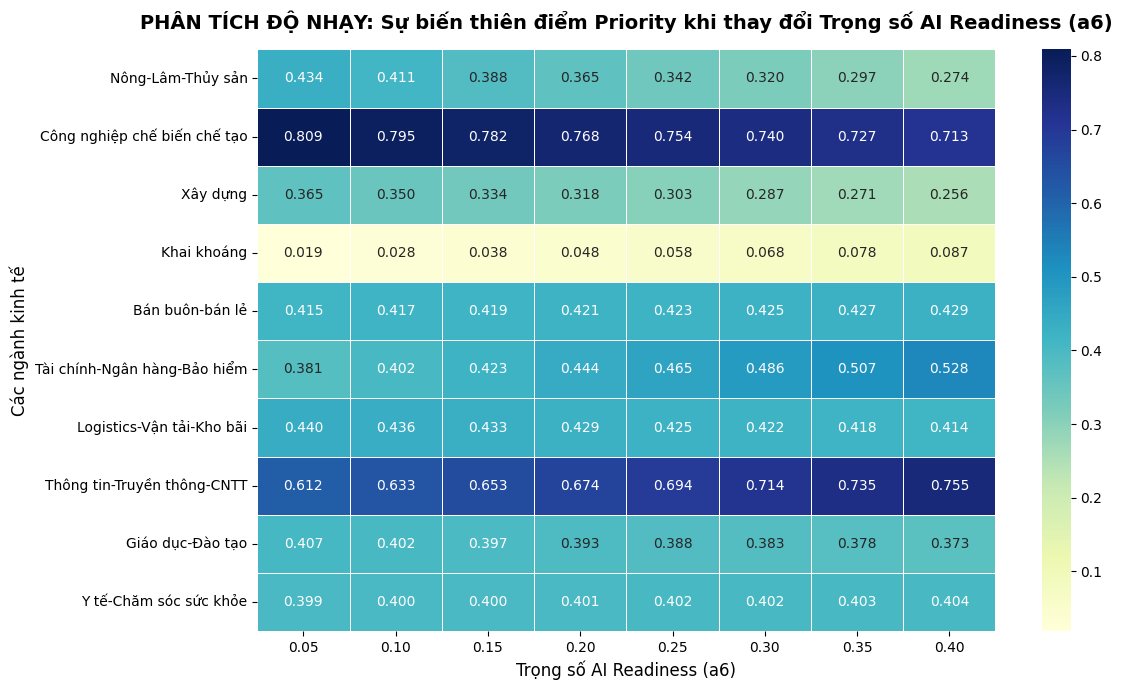

Nhận xét thay đổi Top-3:
 - Tại trọng số a6 = 0.05: Top-3 là ['Công nghiệp chế biến chế tạo', 'Thông tin-Truyền thông-CNTT', 'Logistics-Vận tải-Kho bãi']
 - Tại trọng số a6 = 0.10: Top-3 là ['Công nghiệp chế biến chế tạo', 'Thông tin-Truyền thông-CNTT', 'Logistics-Vận tải-Kho bãi']
 - Tại trọng số a6 = 0.15: Top-3 là ['Công nghiệp chế biến chế tạo', 'Thông tin-Truyền thông-CNTT', 'Logistics-Vận tải-Kho bãi']
 - Tại trọng số a6 = 0.20: Top-3 là ['Công nghiệp chế biến chế tạo', 'Thông tin-Truyền thông-CNTT', 'Tài chính-Ngân hàng-Bảo hiểm']
 - Tại trọng số a6 = 0.25: Top-3 là ['Công nghiệp chế biến chế tạo', 'Thông tin-Truyền thông-CNTT', 'Tài chính-Ngân hàng-Bảo hiểm']
 - Tại trọng số a6 = 0.30: Top-3 là ['Công nghiệp chế biến chế tạo', 'Thông tin-Truyền thông-CNTT', 'Tài chính-Ngân hàng-Bảo hiểm']
 - Tại trọng số a6 = 0.35: Top-3 là ['Thông tin-Truyền thông-CNTT', 'Công nghiệp chế biến chế tạo', 'Tài chính-Ngân hàng-Bảo hiểm']
 - Tại trọng số a6 = 0.40: Top-3 là ['Thông tin-Truyền thông

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mảng lưu trữ các bước thay đổi của a6 từ 0.05 đến 0.40 với bước 0.05
a6_values = np.arange(0.05, 0.45, 0.05)
heatmap_data = []

# Bộ trọng số cố định ban đầu của các yếu tố khác
w_others = np.array([0.15, 0.15, 0.20, 0.15, 0.10, 0.15]) # 5 biến tốt còn lại + 1 biến rủi ro

for a6 in a6_values:
    # Chuẩn hóa lại tổng các trọng số khác sao cho tổng toàn bộ bằng 1
    # Tổng trọng số còn lại phải bằng 1 - a6
    sum_others = w_others.sum()
    w_adjusted = (w_others / sum_others) * (1.0 - a6)
    
    # Tách trọng số ra lại cho 6 biến tốt và 1 biến xấu
    w_g_step = np.append(w_adjusted[:-1], a6)
    w_b_step = w_adjusted[-1]
    
    # Tính điểm Priority tương ứng
    score_step = Xg.values @ w_g_step + w_b_step * Xb.values
    heatmap_data.append(score_step)

# Tạo DataFrame biểu diễn sự thay đổi điểm số của các ngành theo từng mức a6
df_heatmap = pd.DataFrame(np.array(heatmap_data).T, index=df['sector_name_vi'], columns=[f"{a:.2f}" for a in a6_values])

# Vẽ biểu đồ Heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(df_heatmap, annot=True, cmap="YlGnBu", fmt=".3f", linewidths=.5)
plt.title('PHÂN TÍCH ĐỘ NHẠY: Sự biến thiên điểm Priority khi thay đổi Trọng số AI Readiness (a6)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Trọng số AI Readiness (a6)', fontsize=12)
plt.ylabel('Các ngành kinh tế', fontsize=12)
plt.tight_layout()
plt.show()

print("Nhận xét thay đổi Top-3:")
for col in df_heatmap.columns:
    top3 = df_heatmap[col].nlargest(3).index.tolist()
    print(f" - Tại trọng số a6 = {col}: Top-3 là {top3}")

## Câu 3.4.4 - So sánh hai bộ trọng số: "Định hướng tăng trưởng" và "Định hướng bao trùm"

In [3]:
print("=== CÂU 3.4.4: SO SÁNH HAI ĐỊNH HƯỚNG CHÍNH SÁCH ===")

# 1. Bộ trọng số Định hướng tăng trưởng (Ưu tiên: Tăng trưởng, Năng suất, Xuất khẩu)
# Gán trọng số cao cho: Growth (0.25), Productivity (0.25), Export (0.25). Còn lại thấp (0.05)
w_growth_good = np.array([0.25, 0.25, 0.05, 0.25, 0.05, 0.10])
w_growth_risk = 0.05

df['Priority_Growth'] = Xg.values @ w_growth_good + w_growth_risk * Xb.values
rank_growth = df[['sector_name_vi', 'Priority_Growth']].sort_values('Priority_Growth', ascending=False).reset_index(drop=True)

# 2. Bộ trọng số Định hướng bao trùm (Ưu tiên: Việc làm, Lan tỏa, Giảm rủi ro)
# Gán trọng số cao cho: Spillover (0.25), Employment (0.25), Giảm rủi ro (0.25). Còn lại thấp (0.05)
w_inclusive_good = np.array([0.05, 0.05, 0.25, 0.05, 0.25, 0.10])
w_inclusive_risk = 0.25

df['Priority_Inclusive'] = Xg.values @ w_inclusive_good + w_inclusive_risk * Xb.values
rank_inclusive = df[['sector_name_vi', 'Priority_Inclusive']].sort_values('Priority_Inclusive', ascending=False).reset_index(drop=True)

# Hiển thị bảng so sánh Top-5 của hai phương án
compare_df = pd.DataFrame({
    'Hạng': range(1, 6),
    'Định hướng Tăng trưởng': rank_growth['sector_name_vi'].head(5),
    'Điểm (Tăng trưởng)': rank_growth['Priority_Growth'].head(5).round(4),
    'Định hướng Bao trùm': rank_inclusive['sector_name_vi'].head(5),
    'Điểm (Bao trùm)': rank_inclusive['Priority_Inclusive'].head(5).round(4)
})
display(compare_df)

=== CÂU 3.4.4: SO SÁNH HAI ĐỊNH HƯỚNG CHÍNH SÁCH ===


,Hạng,Định hướng Tăng trưởng,Điểm (Tăng trưởng),Định hướng Bao trùm,Điểm (Bao trùm)
0,1,Công nghiệp chế biến chế tạo,0.8980,Công nghiệp chế biến chế tạo,0.7019
1,2,Thông tin-Truyền thông-CNTT,0.5557,Thông tin-Truyền thông-CNTT,0.6122
2,3,Bán buôn-bán lẻ,0.3909,Nông-Lâm-Thủy sản,0.5684
3,4,Logistics-Vận tải-Kho bãi,0.3875,Giáo dục-Đào tạo,0.4680
4,5,Tài chính-Ngân hàng-Bảo hiểm,0.3475,Bán buôn-bán lẻ,0.4609
